# Rate-coded MNIST: single-layer and multilayer LIF networks

This notebook trains two all-LIF classifiers on MNIST with rate coding. It is a
port of `examples/mnist.py`, keeping the same hyperparameters, helper functions,
and training loop. Run it from the repo root with `uv run --extra cu130`.

- single-layer: `Linear(784, 10) -> LIF` (sigmoid readout)
- multilayer: `Linear(784, 256) -> LIF x3 -> Linear(256, 10) -> LIF` (sigmoid readout)


In [1]:
%matplotlib inline
import time
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision

from crematorium.nn import Sequential
from crematorium.snn import LIF
from crematorium.util.surrogate_gradients import sigmoid_surrogate


## Rate coding

`T` timesteps, `B` images per batch, `F = 784` pixels. Each image is fed for
`T` timesteps: `rate()` expands a static `(B, F)` input into a `(T, B, F)`
sequence where every timestep repeats the same image. The mean readout spike
rate over time is the class logit, scaled by `GAIN` — a bounded `[0, 1]` spike
rate needs a gain to be a useful logit for cross-entropy.


In [2]:
T = 25          # rate-coding timesteps
BATCH = 256
LR = 1e-3
GAIN = 10.0     # logit gain: bounded [0, 1] spike rates get a useful scale
CACHE = Path.home() / ".cache" / "crematorium" / "mnist"
EPOCHS = 2      # script default: --epochs 2


## Models

Both networks are built only from LIF neurons; the affine transforms are plain
`nn.Linear`. Pure LIFs cannot mix features — each neuron only integrates its own
input channel — so a small number of Linears is unavoidable. The multilayer net
keeps Linears to a minimum and lets the extra LIF layers carry the compute; that
is where the fused scan pays off.

The readout LIF uses a **sigmoid surrogate** rather than the default
straight-through surrogate. The readout must emit a `0/1` spike per class, and
the straight-through gradient fires everywhere the membrane is above threshold,
which makes a `0/1` readout unstable under cross-entropy. The sigmoid surrogate
(`sigmoid_surrogate(10.0)`) keeps a hard threshold forward but uses the sigmoid
derivative backward, giving smooth, bounded gradients that train reliably.


In [3]:
def readout() -> LIF:
    return LIF(spike_grad=sigmoid_surrogate(10.0))


def single_layer() -> Sequential:
    return Sequential(
        nn.Flatten(),
        nn.Linear(784, 10),
        readout(),
    )


def multilayer() -> Sequential:
    return Sequential(
        nn.Flatten(),
        nn.Linear(784, 256),
        LIF(),
        LIF(),
        LIF(),
        nn.Linear(256, 10),
        readout(),
    )


## `Sequential` owns the state

`crematorium.nn.Sequential` is a plain `nn.Module` topology manager: it threads a
flat state tuple through a time-major scan. Stateful LIF layers stay pure
functions (`init_hidden=False`); the container builds the state bundle via
`initial_state` and runs the whole stack as one step function. That means
`fast_sequence_()` compiles a **single fused scan** over every layer — one
`torch.compile` boundary for the entire network.


In [4]:
def rate(x: torch.Tensor) -> torch.Tensor:
    return x.unsqueeze(0).expand(T, -1, -1)


def logits(net: Sequential, x: torch.Tensor) -> torch.Tensor:
    x_seq = rate(x)
    state = net.initial_state((x.shape[0], x.shape[1]), device=x.device, dtype=x.dtype)
    spikes, *_ = net.forward_sequence(x_seq, state)
    return GAIN * spikes.mean(0)


def evaluate(net: Sequential, x: torch.Tensor, y: torch.Tensor) -> float:
    net.eval()
    correct = 0
    with torch.no_grad():
        for i in range(0, len(x), BATCH):
            pred = logits(net, x[i : i + BATCH])
            correct += (pred.argmax(1) == y[i : i + BATCH]).sum().item()
    return correct / len(y)


## Data

MNIST is downloaded to the cache path on first use, then normalized to `[0, 1]`
and flattened to 784-d vectors. `torch.manual_seed(0)` fixes the shuffle and the
LIF init, matching the script.


In [5]:
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_set = torchvision.datasets.MNIST(CACHE, train=True, download=True)
test_set = torchvision.datasets.MNIST(CACHE, train=False, download=True)

x = torch.tensor(train_set.data, dtype=torch.float32).div_(255.0).view(-1, 784).to(device)
y = torch.tensor(train_set.targets, device=device)
test_x = torch.tensor(test_set.data, dtype=torch.float32).div_(255.0).view(-1, 784).to(device)
test_y = torch.tensor(test_set.targets, device=device)


/tmp/ipykernel_1101733/1685132661.py:7: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = torch.tensor(train_set.data, dtype=torch.float32).div_(255.0).view(-1, 784).to(device)
/tmp/ipykernel_1101733/1685132661.py:8: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y = torch.tensor(train_set.targets, device=device)
/tmp/ipykernel_1101733/1685132661.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_x = torch.tensor(test_set.data, dtype=torch.float32).div_(255.0).view(-1, 784).to(device)
/tmp/ipykernel_1101733/1685132661.py:10: UserWarn

## Training

Per-epoch pass over the shuffled train set with Adam (`LR=1e-3`) and
`CrossEntropyLoss` on the rate-coded logits, then a full evaluation on the test
set. Gradients flow through the unrolled sequence scan via BPTT.


In [6]:
def train(
    net: Sequential,
    x: torch.Tensor,
    y: torch.Tensor,
    test_x: torch.Tensor,
    test_y: torch.Tensor,
    epochs: int,
    compile_scan: bool,
) -> tuple[list[float], list[float]]:
    if compile_scan:
        net.fast_sequence_()

    opt = torch.optim.Adam(net.parameters(), lr=LR)
    loss_fn = nn.CrossEntropyLoss()

    train_loss: list[float] = []
    test_acc: list[float] = []
    n = len(x)
    for epoch in range(epochs):
        net.train()
        perm = torch.randperm(n)
        running = 0.0
        t0 = time.time()

        for i in range(0, n, BATCH):
            idx = perm[i : i + BATCH]
            opt.zero_grad()
            loss = loss_fn(logits(net, x[idx]), y[idx])
            loss.backward()
            opt.step()
            running += loss.item()
            train_loss.append(loss.item())

        acc = evaluate(net, test_x, test_y)
        test_acc.append(acc)
        print(
            f"  epoch {epoch + 1}: loss {running / (n / BATCH):.4f}  "
            f"test acc {acc:.4f}  ({time.time() - t0:.1f}s)",
            flush=True,
        )

    return train_loss, test_acc


## Optional: compile the fused scan

The script's `--compile` flag calls `net.fast_sequence_()` before training,
compiling the whole stack as one fused scan. The default path is eager; flip
`COMPILE = True` below to enable it.


In [7]:
COMPILE = False  # like the script's --compile flag; default is eager


## Single-layer network

`Linear(784, 10) -> LIF` readout: one LIF per class.


In [8]:
print("single-layer (Linear 784->10, LIF)")
net = single_layer().to(device)
single_loss, single_acc = train(net, x, y, test_x, test_y, EPOCHS, COMPILE)


single-layer (Linear 784->10, LIF)


/tmp/ipykernel_1101733/2070392683.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:822.)
  running += float(loss)


  epoch 1: loss 1.8317  test acc 0.3742  (2.2s)


  epoch 2: loss 1.7762  test acc 0.3753  (2.0s)


## Multilayer network

`Linear(784, 256) -> LIF x3 -> Linear(256, 10) -> LIF` readout.


In [9]:
print("multilayer (Linear 784->256, LIF x3, Linear 256->10, LIF)")
net = multilayer().to(device)
multi_loss, multi_acc = train(net, x, y, test_x, test_y, EPOCHS, COMPILE)


multilayer (Linear 784->256, LIF x3, Linear 256->10, LIF)


  epoch 1: loss 0.7466  test acc 0.8182  (5.2s)


  epoch 2: loss 0.3760  test acc 0.9271  (5.4s)


## Results

The single-layer net plateaus quickly around 37% test accuracy, while the
multilayer net climbs past 90% by epoch 2. The two-panel figure shows both
curves on each panel: the left plots per-batch train loss (x = batch index),
the right per-epoch test accuracy with the y-axis pinned to `[0, 1]`. The
per-batch loss panel exposes the learning dynamics that two per-epoch accuracy
points hide — the single-layer loss barely moves while the multilayer loss
drops steadily. Saved to `examples/mnist_accuracy.png`.


saved /home/theguywhoburns/Desktop/crematorium/examples/mnist_accuracy.png


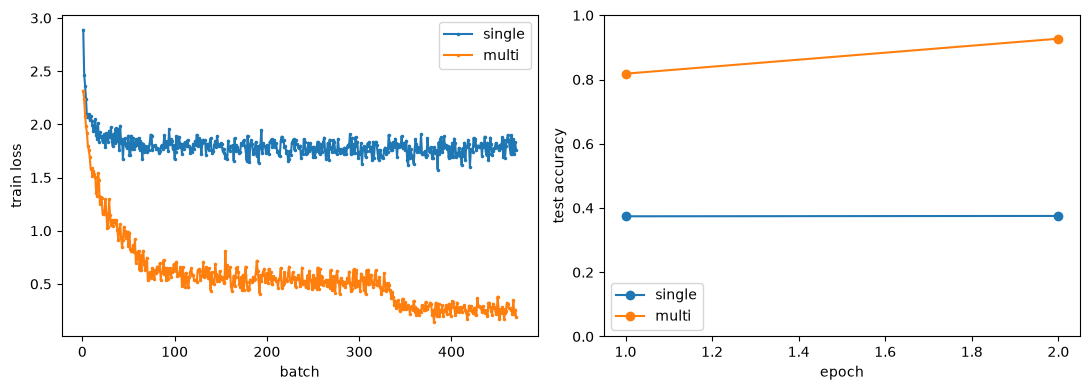

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for name, loss, acc in [("single", single_loss, single_acc), ("multi", multi_loss, multi_acc)]:
    axes[0].plot(range(1, len(loss) + 1), loss, marker=".", ms=3, label=name)
    axes[1].plot(range(1, len(acc) + 1), acc, marker="o", label=name)
axes[0].set_xlabel("batch")
axes[0].set_ylabel("train loss")
axes[0].legend()
axes[1].set_xlabel("epoch")
axes[1].set_ylabel("test accuracy")
axes[1].set_ylim(0, 1)
axes[1].legend()
fig.tight_layout()

# Notebooks have no __file__; resolve relative to the notebook dir so this
# works whether run from the repo root or from examples/ itself.
cwd = Path.cwd()
out = (cwd / "examples" / "mnist_accuracy.png") if (cwd / "examples").is_dir() else cwd / "mnist_accuracy.png"
fig.savefig(out)
print(f"saved {out}")
plt.show()
